<a href="https://colab.research.google.com/github/skywalker0803r/CFB/blob/main/%E6%BB%BE%E5%8B%95%E5%BC%8F%E9%A0%90%E6%B8%ACy1_R20950_aa1_%E5%98%97%E8%A9%A6%E9%A0%90%E6%B8%AC%E6%9B%B4%E4%B9%85%E7%9A%84%E6%9C%AA%E4%BE%86.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# load data

In [43]:
import pandas as pd

df = pd.read_csv('aa1.csv')
df['Time'] = pd.to_datetime(df['Time'])
df.set_index('Time', inplace=True)
for i in df.columns:
    df[i] = pd.to_numeric(df[i], errors='coerce')
df_original = df.copy()
df.head()

,DeSOx_1st,MLUT4_AIA792101A,MLUT4_AIA792101B,MLUT4_AT.232A,MLUT4_AT.237,MLUT4_FIC.231A,MLUT4_FIC.231B,MLUT4_FIC.231C,MLUT4_FIC.233,MLUT4_FIQ.2BTCF,...,MLUT4_TE.953B,MLUT4_TE.954A,MLUT4_TE.954B,MLUT4_FT.956,MLUT4_FT.957,MLUT4_IT.B7926A,MLUT4_IT.B7926B,MLUT4_IT.B7926C,前爐SOx濃度,鈣硫比
Time,,,,,,,,,,,,,,,,,,,,,
2025-05-24 20:10:05,0.944498,0.834203,0.834851,0.808040,0.834945,0.853815,0.834871,0.848672,0.867306,0.828364,...,0.865156,0.849654,0.848231,0.835142,0.834854,0.841315,0.836376,0.835107,0.830004,0.852204
2025-05-24 20:15:05,0.936434,0.834202,0.834851,0.810120,0.836131,0.853365,0.841099,0.851855,0.871343,0.826861,...,0.861791,0.845979,0.846059,0.835086,0.834814,0.839701,0.836364,0.835107,0.828788,0.852239
2025-05-24 20:20:05,0.937028,0.834202,0.834851,0.810093,0.833674,0.852915,0.841957,0.851862,0.869287,0.826698,...,0.858262,0.845860,0.845698,0.835167,0.834921,0.838707,0.836703,0.835107,0.820298,0.852237
2025-05-24 20:25:05,0.930160,0.834202,0.834850,0.812921,0.835420,0.852465,0.841035,0.851869,0.872714,0.826556,...,0.852688,0.840529,0.840165,0.835184,0.835014,0.837590,0.836734,0.835107,0.825153,0.866033
2025-05-24 20:30:05,0.917479,0.834202,0.834941,0.816984,0.831530,0.852015,0.842244,0.851877,0.860490,0.826538,...,0.844138,0.841710,0.841321,0.835137,0.834900,0.838879,0.836945,0.835107,0.822762,0.854453


In [44]:
特徵篩選結果 = pd.read_excel('/content/特徵篩選結果（10s間隔彙整後）.xlsx',sheet_name='Y1')
features = list(特徵篩選結果.head(40)['Feature'])
print(features)
特徵篩選結果.head()

['MLUT4_FIC.231A', '前爐SOx濃度', 'MLUT4_RQ.2BTLS', 'MLUT4_AT.232A', 'MLUT4_PDT.232', 'MLUT4_IT.79021C', 'MLUT4_FT.792003', 'MLUT4_TE.252B', 'MLUT4_TE.953B', 'MLUT4_TE.251F', 'MLUT4_PDT.956', 'MLUT4_FIQ.2BTCF', 'MLUT4_TE.256A', '鈣硫比', 'MLUT4_TE.251H', 'MLUT4_TE.252A', 'MLUT4_TE.252D', 'MLUT4_FT.951AB', 'MLUT4_PIC.233', 'MLUT4_FQ.239', 'MLUT4_IT.79021B', 'MLUT4_TE.255A', 'MLUT4_PT.231', 'MLUT4_TE.251D', 'MLUT4_ZT.232', 'MLUT4_FT.V004', 'MLUT4_TE.252G', 'MLUT4_FT.232', 'MLUT4_TE.256B', 'MLUT4_FIC.231B', 'MLUT4_AIA792101A', 'MLUT4_RT.041', 'MLUT4_TE.251B', 'MLUT4_TE.951B', 'MLUT4_FT.957', 'MLUT4_TE.251I', 'MLUT4_TE.252H', 'MLUT4_IT.E7925B', 'MLUT4_TE.253A', 'MLUT4_FQ.205']


,Feature,pearson_score,lasso_score,permutation_score,rfe_score,rf_score,total_score,final_rank,Varv,import
0,MLUT4_FIC.231A,85,55,70,87,85,382,1.0,飼料機A,V
1,前爐SOx濃度,76,72,76,67,83,374,2.0,NaN,NaN
2,MLUT4_RQ.2BTLS,59,85,88,52,87,371,3.0,石灰石,V
3,MLUT4_AT.232A,87,73,87,32,86,365,4.0,ECO_NOx,NaN
4,MLUT4_PDT.232,57,66,69,83,74,349,5.0,上層壓差,NaN


In [45]:
dataall = pd.read_csv('/content/Datall(d).csv')
dataall['Time'] = pd.to_datetime(dataall['Time'])
dataall.set_index('Time', inplace=True)
dataall.head()

,MLUT4_AT.240,MLUT4_FIQ.2BTCF,DeSOx_1st,DeSOx_2nd
Time,,,,
2025-05-24 20:02:45,0.075534,39.117515,0.931564,0.998008
2025-05-24 20:02:55,0.075027,39.152805,0.932554,0.997993
2025-05-24 20:03:05,0.074521,39.178716,0.933661,0.997977
2025-05-24 20:03:15,0.074014,39.201588,0.934563,0.997967
2025-05-24 20:03:25,0.073507,39.224352,0.935067,0.997957


# help function

In [46]:
def select_by_rule(df):
  coal_low = df[df["MLUT4_FIQ.2BTCF"] < 20]
  sox = df["MLUT4_AT.240"]
  constant_sox_indices = sox[sox.shift(1) == sox][(sox.shift(2) == sox) & (sox.shift(-1) == sox)].index
  constant_sox = df.loc[constant_sox_indices]
  common_index = coal_low.index.union(constant_sox.index)
  return common_index

# main

In [47]:
import pandas as pd
import xgboost as xgb
import numpy as np
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import pickle
from pykalman import KalmanFilter
from tqdm import tqdm

df_metrics_list = []
result_df_list = []

for i in tqdm(range(1,10)):
  df['DeSOx_1st'] = df_original['DeSOx_1st'].shift(-i)

  # select_by_rule
  common_index = select_by_rule(dataall)
  select_df = df.loc[~df.index.isin(common_index), :]

  # select features
  features = list(特徵篩選結果.head(40)['Feature'])

  # define y_col
  y_col = 'DeSOx_1st'
  select_df = select_df[features+[y_col]]

  # --- Modeling Code (Corrected Part) ---
  def train_model(train_X, train_y):
      model = xgb.XGBRegressor(
          n_estimators=900,
          random_state=42,
          n_jobs=-1,
          learning_rate=0.028,
          max_depth=8,
          subsample=0.75,
          colsample_bytree=0.75,
          objective='reg:squarederror',
          tree_method='hist'
      )
      return model.fit(train_X, train_y)

  # 1. 時間排序
  select_df = select_df.sort_index()

  # 2. 設定
  target_col = y_col
  time_windows_len = 100 #<--- 調整這裡

  # 加入前一期目標欄位當特徵
  select_df["prev_target"] = select_df[target_col].shift(1)

  # 效率不應該低於0
  select_df = select_df[select_df["prev_target"]>0]
  select_df = select_df[select_df[y_col]>0]

  # 卡爾曼濾波
  def apply_kalman_filter(series,transition_covariance=0.3,observation_covariance=1.0,initial_state_covariance=1.0):
      series = series.fillna(method='ffill')
      kf = KalmanFilter(
          initial_state_mean=series.iloc[0],
          initial_state_covariance=initial_state_covariance,
          transition_matrices=1.0,
          observation_matrices=1.0,
          transition_covariance=transition_covariance,
          observation_covariance=observation_covariance,
          n_dim_obs=1
      )
      state_means, _ = kf.smooth(series.values)
      return state_means.flatten()

  # 套用卡爾曼濾波
  select_df["prev_target"] = apply_kalman_filter(select_df["prev_target"])
  select_df[y_col] = apply_kalman_filter(select_df[y_col])


  # 刪除因 shift 產生的 NaN 資料
  select_df = select_df.dropna().sort_index()

  # 定義特徵欄位除了時間跟target_col不能用其他都可以用
  feature_cols = [col for col in select_df.columns if col not in ['timestamp', target_col]]

  # 開始訓練的索引
  start_idx = time_windows_len

  # 計算total_steps
  total_steps = len(select_df) - start_idx

  # 3. 儲存預測結果
  predictions = []
  abs_errors = []
  thresholds = []
  indices = []

  # To store recent errors for threshold calculation for the *current* model
  current_model_recent_errors = []
  threshold_update_window = 100 # Calculate threshold from last 100 errors
  percentile_for_threshold = 90 # 90th percentile of recent errors

  # 4. 初始化進度條
  pbar = tqdm(total=total_steps)

  # 5. 動態預測迴圈
  i = start_idx
  error_exceeded_threshold = True  # Start with training a model

  while i < len(select_df):
      # 早停判斷<不得移除>
      if pbar.n >= 1000: # This means it will stop after 1500 predictions, not 1000 training steps.
          break

      # 判斷是否要建模 並記錄
      if 'current_model' not in locals() or error_exceeded_threshold:
          train_df = select_df.iloc[i - time_windows_len:i]
          train_X = train_df[feature_cols]
          train_y = train_df[target_col]

          # train model start
          current_model = train_model(train_X, train_y)

          # Reset recent errors for the new model
          current_model_recent_errors = []
          # For the first prediction after re-training, we won't have enough recent errors
          # to calculate a meaningful threshold. We can set a default or wait.
          # Here, we'll simply let the first few errors build up before calculating.
          current_threshold = np.inf # Set a very high threshold initially for a newly trained model

          error_exceeded_threshold = False # Reset flag

      # 預測i
      test_row = select_df.iloc[i]
      test_X = test_row[feature_cols].values.reshape(1, -1)
      true_y = test_row[target_col]
      pred_y = current_model.predict(test_X)[0]
      error = abs(pred_y - true_y)

      # Add the current error to the list of recent errors for this model
      current_model_recent_errors.append(error)

      # If we have enough recent errors, calculate the threshold for the *current* model's performance
      if len(current_model_recent_errors) >= threshold_update_window:
          current_threshold = np.percentile(current_model_recent_errors[-threshold_update_window:], percentile_for_threshold)
      elif len(current_model_recent_errors) > 0: # If less than window size, use all available errors
          current_threshold = np.percentile(current_model_recent_errors, percentile_for_threshold)
      else:
          current_threshold = np.inf # Should ideally not happen after first few predictions

      # 紀錄
      predictions.append(pred_y)
      abs_errors.append(error)
      thresholds.append(current_threshold)
      indices.append(i)

      # 更新進度條
      pbar.update(1)

      # 根據預測i的結果判斷是否要設置error_exceeded_threshold
      # The check for re-training now uses the threshold calculated from actual recent test errors
      if error > current_threshold:
          error_exceeded_threshold = True
          # If error exceeds, a new model will be trained in the next iteration
          # and 'i' increments by 1
          i += 1
      else:
          # If error does not exceed, stay with the current model for the next prediction
          # 'i' increments by 1, and the loop will try to predict 'i+1' with the *same* model
          i += 1
          error_exceeded_threshold = False # Continue using current model

  # 結束訓練
  pbar.close()

  # 6. 輸出結果表
  result_df = select_df.iloc[indices].copy()
  result_df['prediction'] = predictions
  result_df['abs_error'] = abs_errors
  result_df['threshold'] = thresholds

  # 預覽結果
  print(result_df.head())

  from sklearn.metrics import r2_score, mean_squared_error
  import numpy as np

  # 指標評估
  y_true = result_df[y_col]
  y_pred = result_df['prediction']

  # Calculate R-squared
  r2 = r2_score(y_true, y_pred)
  # Calculate RMSE
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  # Calculate MAPE
  mape = np.mean(np.abs((y_true - y_pred) / y_true[y_true != 0])) * 100 if np.any(y_true != 0) else 0


  # 假設 r2, rmse, mape 是事先計算好的指標
  metrics = {
      'Metric': ['R-squared', 'RMSE', 'MAPE'],
      'Value': [r2, rmse, mape],
      'Unit': ['', '', '%']
  }

  df_metrics = pd.DataFrame(metrics)
  result_df_list.append(result_df)
  df_metrics_list.append(df_metrics)

 11%|█         | 1/9 [03:30<28:05, 210.63s/it]

                     MLUT4_FIC.231A   前爐SOx濃度  MLUT4_RQ.2BTLS  MLUT4_AT.232A  \
Time                                                                           
2025-05-25 05:20:05        0.853117  0.824491        0.817427       0.849982   
2025-05-25 05:30:05        0.855030  0.819804        0.830773       0.830232   
2025-05-25 05:35:05        0.857551  0.819510        0.832418       0.830533   
2025-05-25 05:40:05        0.854254  0.826565        0.822751       0.828833   
2025-05-25 05:45:05        0.853725  0.833322        0.837547       0.830431   

                     MLUT4_PDT.232  MLUT4_IT.79021C  MLUT4_FT.792003  \
Time                                                                   
2025-05-25 05:20:05       0.852211         0.871596          0.84859   
2025-05-25 05:30:05       0.852083         0.871309          0.84859   
2025-05-25 05:35:05       0.850891         0.871653          0.84859   
2025-05-25 05:40:05       0.851766         0.871739          0.84859   
2025-05


 22%|██▏       | 2/9 [06:58<24:21, 208.78s/it]

                     MLUT4_FIC.231A   前爐SOx濃度  MLUT4_RQ.2BTLS  MLUT4_AT.232A  \
Time                                                                           
2025-05-25 05:20:05        0.853117  0.824491        0.817427       0.849982   
2025-05-25 05:30:05        0.855030  0.819804        0.830773       0.830232   
2025-05-25 05:35:05        0.857551  0.819510        0.832418       0.830533   
2025-05-25 05:40:05        0.854254  0.826565        0.822751       0.828833   
2025-05-25 05:45:05        0.853725  0.833322        0.837547       0.830431   

                     MLUT4_PDT.232  MLUT4_IT.79021C  MLUT4_FT.792003  \
Time                                                                   
2025-05-25 05:20:05       0.852211         0.871596          0.84859   
2025-05-25 05:30:05       0.852083         0.871309          0.84859   
2025-05-25 05:35:05       0.850891         0.871653          0.84859   
2025-05-25 05:40:05       0.851766         0.871739          0.84859   
2025-05


 33%|███▎      | 3/9 [10:20<20:35, 205.88s/it]

...

                     MLUT4_FIC.231A   前爐SOx濃度  MLUT4_RQ.2BTLS  MLUT4_AT.232A  \
Time                                                                           
2025-05-25 05:20:05        0.853117  0.824491        0.817427       0.849982   
2025-05-25 05:30:05        0.855030  0.819804        0.830773       0.830232   
2025-05-25 05:35:05        0.857551  0.819510        0.832418       0.830533   
2025-05-25 05:40:05        0.854254  0.826565        0.822751       0.828833   
2025-05-25 05:45:05        0.853725  0.833322        0.837547       0.830431   

                     MLUT4_PDT.232  MLUT4_IT.79021C  MLUT4_FT.792003  \
Time                                                                   
2025-05-25 05:20:05       0.852211         0.871596          0.84859   
2025-05-25 05:30:05       0.852083         0.871309          0.84859   
2025-05-25 05:35:05       0.850891         0.871653          0.84859   
2025-05-25 05:40:05       0.851766         0.871739          0.84859   
2025-05


 89%|████████▉ | 8/9 [27:07<03:21, 201.48s/it]

                     MLUT4_FIC.231A   前爐SOx濃度  MLUT4_RQ.2BTLS  MLUT4_AT.232A  \
Time                                                                           
2025-05-25 05:20:05        0.853117  0.824491        0.817427       0.849982   
2025-05-25 05:30:05        0.855030  0.819804        0.830773       0.830232   
2025-05-25 05:35:05        0.857551  0.819510        0.832418       0.830533   
2025-05-25 05:40:05        0.854254  0.826565        0.822751       0.828833   
2025-05-25 05:45:05        0.853725  0.833322        0.837547       0.830431   

                     MLUT4_PDT.232  MLUT4_IT.79021C  MLUT4_FT.792003  \
Time                                                                   
2025-05-25 05:20:05       0.852211         0.871596          0.84859   
2025-05-25 05:30:05       0.852083         0.871309          0.84859   
2025-05-25 05:35:05       0.850891         0.871653          0.84859   
2025-05-25 05:40:05       0.851766         0.871739          0.84859   
2025-05


100%|██████████| 9/9 [30:46<00:00, 205.21s/it]

                     MLUT4_FIC.231A   前爐SOx濃度  MLUT4_RQ.2BTLS  MLUT4_AT.232A  \
Time                                                                           
2025-05-25 05:20:05        0.853117  0.824491        0.817427       0.849982   
2025-05-25 05:30:05        0.855030  0.819804        0.830773       0.830232   
2025-05-25 05:35:05        0.857551  0.819510        0.832418       0.830533   
2025-05-25 05:40:05        0.854254  0.826565        0.822751       0.828833   
2025-05-25 05:45:05        0.853725  0.833322        0.837547       0.830431   

                     MLUT4_PDT.232  MLUT4_IT.79021C  MLUT4_FT.792003  \
Time                                                                   
2025-05-25 05:20:05       0.852211         0.871596          0.84859   
2025-05-25 05:30:05       0.852083         0.871309          0.84859   
2025-05-25 05:35:05       0.850891         0.871653          0.84859   
2025-05-25 05:40:05       0.851766         0.871739          0.84859   
2025-05

In [72]:
import pandas as pd

combined_df = pd.DataFrame()

for idx, item in enumerate(df_metrics_list):
    # 假設每個 item 都有一欄叫 'Metric'，並在轉置後只取一列數據
    row = item.set_index('Metric').T.iloc[0]
    combined_df = pd.concat([combined_df, row], axis=1)

# 命名欄位
combined_df.columns = [f't+{i}' for i in range(1, len(df_metrics_list)+1)]

combined_df


,t+1,t+2,t+3,t+4,t+5,t+6,t+7,t+8,t+9
R-squared,0.952229,0.954104,0.949812,0.949546,0.950948,0.933968,0.905724,0.91404,0.904223
RMSE,0.00534,0.005328,0.005708,0.005915,0.006029,0.007135,0.008604,0.008233,0.00868
MAPE,0.403762,0.405603,0.411531,0.407604,0.420919,0.462299,0.509967,0.49764,0.50833


<Axes: >

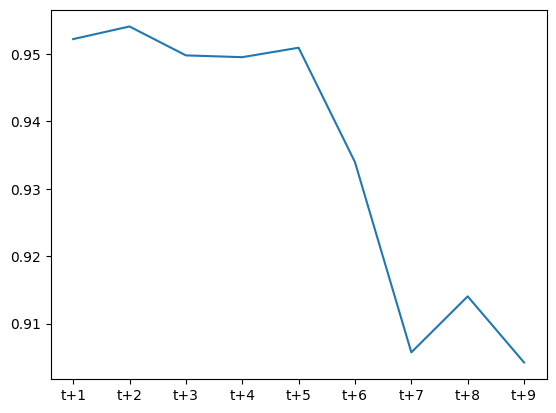

In [73]:
combined_df.loc['R-squared'].plot()